# Playground

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [4]:
import os
import sys
from pathlib import Path
import time
import json
#import diffusers
sys.path.append(os.path.abspath("../diffusionsim"))
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
from pprint import pprint
import matplotlib.pyplot as plt

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'mps'

In [5]:
sys.path

['/Users/samart/miniforge3/envs/arena-env/lib/python311.zip',
 '/Users/samart/miniforge3/envs/arena-env/lib/python3.11',
 '/Users/samart/miniforge3/envs/arena-env/lib/python3.11/lib-dynload',
 '',
 '/Users/samart/miniforge3/envs/arena-env/lib/python3.11/site-packages',
 '/Users/samart/Desktop/Tian Research/diffusion-climsim/Notebooks/diffusionsim',
 '/Users/samart/Desktop/Tian Research/diffusion-climsim/diffusionsim']

In [6]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals

IndentationError: unexpected indent (trainers.py, line 17)

# Debugging Training Classes

In [11]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True

## Diffusion Training

In [3]:
def setup_diffusion_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "xbatch"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [1.0]
    tconfigs, mconfigs = [], []

    learning_rates = [5e-5, 5e-4]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = None
        tconfig.lr_warmup_steps = 500
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 2

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddom_diffusion'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "trial1"

num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [4]:
tconfigs, mconfigs, dconfig = setup_run(num_models, exp_id, run_id,
              data_vars='v1', batch_size=128)

dconfig.train_test_split = [0.001]

In [5]:
trainer = DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)

In [7]:
trainer.train(num_epochs=1)

In [18]:
print(trainer.dataloaders['train'].dataset.data.sizes)
trainer.dataloaders['train'].dataset.bgen._batch_selectors.selectors


In [5]:
dataloaders, indices = tru.load_dataloaders(dconfig)

In [6]:
dataloader_dict = dict(train=dataloaders[0])
loss_fn = torch.nn.MSELoss()

In [6]:
#mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

In [54]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

## Train Clim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type=dataset_type, batch_size=batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.002, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 5e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.01, 0.01, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [20.0, 20.0, 20.0, 20.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 1, 'diffusion': 1}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [8]:
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "testing_just_mse"

In [ ]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTesting"
run_id = ""
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    2, "MultiTask", "testing", data_vars='v1', batch_size=64
)

In [ ]:
#dconfig.train_test_split = [0.001, 0.001]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.002, 0.001],
           dataloader_params=DataLoaderParams(batch_size=24576,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=True)


In [20]:
trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)
self = trainer

NameError: name 'ClimsimTrainer' is not defined

In [152]:
len(trainer.dataloaders['train']), #trainer.indices[0]


In [171]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

### Sanity Checking run_batch

In [ ]:
run = evals.Run()

In [223]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [224]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [226]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


In [227]:
x, y = next(iter(trainer.dataloaders['train']))

In [233]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

In [235]:
params[0] == after_params[0]

In [212]:
after_params[0]

In [135]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

In [56]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

## Implementing GradNorm

In [52]:
from collections import defaultdict
from sklearn.mixture import GaussianMixture

In [ ]:
tconfigs

In [ ]:
AbstractTrainer = trainers.AbstractTrainer
class ClimsimTrainer(AbstractTrainer):
    def __init__(self, dconfig, mconfigs, tconfigs, base_dir, base_run_id, rank=0, indices=None, **kwargs):
        super().__init__(dconfig, mconfigs, tconfigs, base_dir, base_run_id, rank, indices)
        self.tracked_losses = ["mse"]
        self.track_loss_weights = False
        for run_id in self.run_ids:
            loss_weights = self.training_configs[run_id].loss_weights
            if(loss_weights['distribution'] > 0 and "distribution" not in self.tracked_losses):
                self.tracked_losses.append("distribution")
            if(loss_weights['diffusion'] > 0 and "diffusion" not in self.tracked_losses):
                self.tracked_losses.append("diffusion")
            
            if(self.training_configs[run_id].loss_weight_strategy == "gradnorm"):
                self.track_loss_weights = True

        if ("diffusion" in self.tracked_losses):
            self.unet = kwargs['unet'] if('unet' in kwargs) else tru.load_diffusion_model().to(self.device)
            scheds = [kwargs['scheduler'] for _ in range(len(self.run_ids))] if 'scheduler' in kwargs else [tru.load_scheduler(mconfig) for mconfig in self.mconfigs.values()]
            self.schedulers = dict(zip(self.run_ids, scheds))
        #if ("distribution" in self.tracked_losses):
        

    def _make_image(self, y, image_dim=2):
        if not torch.is_tensor(y):
            y = torch.tensor(y)
        ds = self.dataloaders['train'].dataset
        # desired output is (BS, C, H, W)
        return(tru.imagify(y, ds.dutils, 'y', image_dim))

    def setup_training(self, num_epochs, log=True):
        super().setup_training(num_epochs, log)
        self.distloss_var_counts = {}
        if self.track_loss_weights:
            self.loss_weights = {}
            self.lw_optimizers = {}
            for run_id in self.run_ids:
                lws = [self.training_configs[run_id].loss_weights[k] for k in self.tracked_losses]
                self.loss_weights[run_id] = torch.nn.Parameter(torch.tensor(lws))
                self.lw_optimizers[run_id] = torch.optim.Adam([self.loss_weights[run_id]], lr=self.training_config[run_id].gradnorm_lr)
    
    def _return_loss_weights(self, run_id, losses=None):
        tconfig = self.training_configs[run_id]
        match tconfig.loss_weight_strategy:
            case "fixed":
                return(tconfig.loss_weights)
            case "epoch_fixed":
                for loss_type, loss_sched in tconfig.loss_schedule.items():
                    if (isinstance(loss_sched, int) and self.current_epoch < loss_sched):
                        tconfig.loss_weights[loss_type] = 0
                        continue
                    elif isinstance(loss_sched, list) and not (loss_sched[0] <= self.current_epoch < loss_sched[1]):
                        tconfig.loss_weights[loss_type] = 0
            case "gradnorm":
                assert losses is not None, "losses must be provided for gradnorm loss weight strategy"
                # implement gradnorm
                grads = []
                for i, loss_type in enumerate(self.tracked_losses):
                    losses[i].backward(retain_graph=True)
                    grads.append()
                
    
    def apply_loss(self, y_hat, x, y, loss_type, batch_losses, run_id):
        model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
        model.zero_grad()
        if(loss_type == "mse"):
            loss = self.loss_fn(y_hat, y)
        elif(loss_type == "distribution"):
            loss, VAR_IND = self.distribution_loss(y_hat, y, run_id, step)
            self.distloss_var_counts.setdefault(run_id, defaultdict(int))[VAR_IND] += 1
            batch_losses[run_id]['VAR_IND'] = VAR_IND
        elif(loss_type == "diffusion"):
            loss = self.diffusion_loss(y_hat, run_id)
        batch_losses[run_id][loss_type] = loss.item()
        if(self._gradients_ops(run_id, loss_type, loss, step)):
            self.nan_incidents[run_id][-1]['inputs'] = (x, y)
        batch_losses[run_id][loss_type] = loss.item()
        if torch.isnan(loss):
            return ( torch.tensor(0) ) # TODO : Ensure this is correctly excluded from computational graph
        return(loss)


    def _run_batch_ideal(self, x, y, phase, step):
        batch_losses = {}
        for run_id in self.run_ids:
            batch_losses[run_id] = {}
            y_hat = self.models[run_id](x) 
            losses = torch.stack([self.apply_loss(y_hat, x, y, loss_type, batch_losses, run_id) for loss_type in self.tracked_losses])
            loss_weights = self._return_loss_weights(run_id, losses)
            total_loss = loss_weights @ losses
            if phase == 'train':
                self.optimizers[run_id].zero_grad()
                total_loss.backward(retain_graph=True)
                if(self.training_configs[run_id].clip_gradients):
                    total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                self.optimizers[run_id],.step()
                if(self.lr_schedulers[run_id] is not None):
                    self.lr_schedulers[run_id].step()
    
    def _run_batch(self, x, y, phase, step):
        if(self.log):
            t0 = tru.log_event("run-batch start", step=step)
        batch_losses = {}
        for run_id in self.run_ids:
            batch_losses[run_id] = {}
            model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
            lws = self._return_loss_weights(run_id)
            y_hat = model(x)
            mse_loss = self.loss_fn(y_hat, y)
            if(phase == 'train' and self._gradients_ops(run_id, "mse", mse_loss, step)):
                self.nan_incidents[run_id][-1]['inputs'] = (x, y)
            total_loss = lws['mse'] * mse_loss
            batch_losses[run_id]['mse'] = mse_loss.item()
            if('distribution' in self.tracked_losses):
                dist_loss, VAR_IND = self.distribution_loss(y_hat, y, tconfig, step)
                if(phase == 'train' and self._gradients_ops(run_id, "distribution", dist_loss, step)):
                    self.nan_incidents[run_id][-1]['inputs'] = (x, y)
                batch_losses[run_id]['distribution'] = dist_loss.item()
                batch_losses[run_id]['VAR_IND'] = VAR_IND
                if(lws['distribution'] > 0 and not torch.isnan(dist_loss)):
                    total_loss += lws['distribution'] * dist_loss
                
            if('diffusion' in self.tracked_losses):
                diff_loss = self.diffusion_loss(y_hat, run_id)
                if(phase == 'train' and self._gradients_ops(run_id, "diffusion", diff_loss, step)):
                    self.nan_incidents[run_id][-1]['inputs'] = (x, y)
                batch_losses[run_id]['diffusion'] = diff_loss.item()
                if(lws['diffusion'] > 0 and not torch.isnan(diff_loss)):  
                    total_loss += lws['diffusion'] * diff_loss
            
            batch_losses[run_id]['total'] = total_loss.item()
            if(phase == 'train'):
                optimizer.zero_grad()
                total_loss.backward(retain_graph=False)
                if(self.training_configs[run_id].clip_gradients):
                    total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if(self.lr_schedulers[run_id] is not None):
                    self.lr_schedulers[run_id].step()
        losses = [batch_losses[run_id]['total'] for run_id in self.run_ids]
        if(self.log):
            tru.log_event("run-batch end", duration=time.time() - t0, loss=losses, step=step)
        return(batch_losses)
    
    def _gradients_ops(self, run_id, loss_type, loss, step):
        #assert loss_type in self.tracked_losses, f"loss_type {loss_type} must be one of {self.tracked_losses}"
        model, optimizer = self.models[run_id], self.optimizers[run_id]

        def register_incident(self, msg, tensor_name=None, tensor=None):
            print(f"[NaN-Detect] step={step}  {run_id=} {loss_type=}  >>> {msg}", flush=True)
            payload = dict(step=step, run_id=run_id, loss_type=loss_type, msg=msg, 
                           tensor_name=tensor_name, 
                           tensor_sample=tensor.clone().cpu() if tensor is not None else None, 
                           state_dict={k: v.clone().cpu() for k, v in model.state_dict().items()}
            )
            self.nan_incidents.setdefault(run_id, []).append(payload)
        
        if not torch.isfinite(loss):
            register_incident("LOSS is not finite (NaN or Inf)", "loss", loss.detach())
            return -1

        if (self.training_configs[run_id].log_gradients and step % self.bli == 0):
            optimizer.zero_grad(set_to_none=True)           # clean slate
            loss.backward(retain_graph=True)
            gdict = self.gradients.setdefault(run_id, {}).setdefault(loss_type, {})
            for n, p in model.named_parameters():
                if(p.grad is None):
                    continue
                if torch.isfinite(p.grad).all():
                    gdict.setdefault(n, []).append(
                        (p.grad.mean().item(), p.grad.std().item())
                    )
                else:
                    register_incident("GRAD has NaN/Inf", n, p.grad)
                    return -1

        # ------------------------------------------------------------------ #
        # 5. Clean up so real backward sees a fresh gradient buffer
        # ------------------------------------------------------------------ #
        optimizer.zero_grad(set_to_none=True)

        # Let caller know if we saw anything suspicious
        return 0
    
    def distribution_loss(self, y_hat, y, run_id, step, epsilon=1e-3):
        tconfig = self.training_configs[run_id]
        VAR_IND, num_gaussian = trainers.select_distloss_var(tconfig, step)
        self.distloss_var_counts.setdefault(run_id, defaultdict(int))[VAR_IND] += 1
        assert isinstance(num_gaussian, int) and isinstance(VAR_IND, int), "num_gaussian and VAR_IND must be integers"
        GMM = GaussianMixture(n_components=num_gaussian, reg_covar=epsilon)
        GMM.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))
        mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
        pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] 
        var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:]
        pi = torch.clamp(pi, min=epsilon)
        var = torch.clamp(var, min=epsilon)
        
        with torch.no_grad():
            h = 2 * torch.max(var).item()

        bs, n_samples = tconfig.distloss_bs, tconfig.num_distloss_samples
        batch_num = y_hat.shape[0] // bs
        ix, jx = torch.randint(0, batch_num, (n_samples,)), torch.randint(0, batch_num, (n_samples,))
        mask = ix == jx
        while mask.any():
            ix[mask] = torch.randint(0, batch_num, (mask.sum(),))
            jx[mask] = torch.randint(0, batch_num, (mask.sum(),))
            mask = ix == jx
        loss = 0
        for i,j in zip(ix, jx):
            y1 = y_hat[i*bs : (i+1)*bs, VAR_IND]
            y2 = y_hat[j*bs : (j+1)*bs, VAR_IND]
            loss += trainers.u_q(y1, y2, mu, var, pi, h).mean()
        return(loss / n_samples, VAR_IND)
        
    def diffusion_loss(self, y_hat, run_id):
        #raise NotImplementedError("Diffusion loss not implemented")
        # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
        tconfig = self.training_configs[run_id]
        scheduler = self.schedulers[run_id]
        y_image = self._make_image(y_hat, image_dim=2)
        def encode(sample):
            eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
            xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
            return(xt)
        def decode(xt):
            with torch.no_grad():
                for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                    eps_theta = self.unet(xt, t).sample
                    xt = scheduler.step(eps_theta, t, xt).prev_sample
            return(xt)
        y_image_denoised = decode(encode(y_image))
        return(self.loss_fn(y_image_denoised, y_image))

    def finish_training(self, num_epochs):
        super().finish_training(num_epochs, distloss_var_counts=self.distloss_var_counts)

    def _run_epoch(self, epoch, phase='train'):
        for run_id in self.run_ids:
            self.models[run_id].train(phase=='train')

        """
        Tracking 3 kinds of losses, which can be confusing: 
        batch_losses: losses for a single batch. Because there might be many batches in an epoch, do not save every single batch loss
        int current_losses: instead, divide epoch into batch_logging_interval sized sections, and save the mean of the losses for each section
        int[] epoch_losses: the number of loss items saved for a single epoch is (batches_per_epoch / batch_logging_interval) 
        """
        e0 = tru.log_event(f"epoch-{epoch} start")
        epoch_losses = defaultdict(dict)
        with torch.set_grad_enabled(phase=='train'):
            if(self.distributed):
                self.dataloaders[phase].sampler.set_epoch(epoch)
            for step, (X, Y) in enumerate(self.dataloaders[phase]):
                if(step % 100 == 0):
                    print(f"Currently at epoch {epoch}, step {step}/{len(self.dataloaders[phase])}", flush=True)                
                batch_losses = self._run_batch(X.to(self.device), Y.to(self.device), phase, step)
                if(batch_losses is None):
                    print(f"Batch {step} is bad; stopping", flush=True)
                    break
                self.log_step(epoch_losses, batch_losses, step, phase)
                
        tru.log_event(f"epoch-{epoch} end", duration=time.time() - e0)
        return(epoch_losses)
    
    def log_step(self, epoch_losses, batch_losses, step, phase, wandb=True):
        if(wandb):
            wandb_metrics = {"epoch" : self.current_epoch}
            for run_id in self.run_ids:
                if('distribution' in self.tracked_losses):
                    wandb_metrics[f"{phase}/{run_id}/distloss_var"] = batch_losses[run_id]['VAR_IND']
                for loss_type in self.tracked_losses:
                    wandb_metrics[f"{phase}/{run_id}/{loss_type}"] = batch_losses[run_id][loss_type]
            #global_step = self.current_epoch * len(self.dataloaders[phase]) + step
            self.run.log(wandb_metrics)
        
        if (step % self.bli == 0):
            #with open(self.log_file_path, "r") as f:
            #    master_dict = json.load(f)
            for run_id in self.run_ids:
                if('distribution' in self.tracked_losses):
                    epoch_losses[run_id].setdefault('distloss_var', []).append(batch_losses[run_id]['VAR_IND'])
                for loss_type in self.tracked_losses:
                    epoch_losses[run_id].setdefault(loss_type, []).append(batch_losses[run_id][loss_type])
            #    master_dict[run_id][f'{phase}_epoch_losses'] = epoch_losses[run_id]
            #with open(self.log_file_path, "w") as f:
            #    json.dump(master_dict, f)
        
        if ( (step + 1) % self.ckpt_interval == 0 and phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)

    def _log_epoch_info(self, epoch_stats, epoch_num, phase='train'):
        with open(self.log_file_path, "r") as f:
            master_dict = json.load(f)
        print("\n\n", flush=True)
        for run_id in self.run_ids:
            ldict = self.losses.setdefault(run_id, {}).setdefault(phase, {})
            for loss_type in self.tracked_losses:
                ldict[loss_type] = ldict.setdefault(loss_type, []) + epoch_stats[run_id][loss_type]
                avg_loss = sum(epoch_stats[run_id][loss_type]) / len(epoch_stats[run_id][loss_type])
                print(f"avg {loss_type} loss for epoch {epoch_num}, run_id {run_id}: {avg_loss}", flush=True)
                if(phase == 'train' and loss_type == 'total'):
                    if(avg_loss < self.best_losses.setdefault(run_id, float('inf'))):
                        print(f"new best! saving new checkpoint at epoch {epoch_num}", flush=True)
                        self.best_losses[run_id] = avg_loss
                        self._save_checkpoint(run_id, cid='best-')
            
                master_dict[run_id].setdefault('losses', {}).setdefault(phase, {}).setdefault(loss_type, []).extend(ldict[loss_type])
                
                if(phase == 'train'):
                    master_dict[run_id]['gradients'] = self.gradients[run_id]
            master_dict[run_id][f'{phase}_epoch_losses'] = None

        with open(self.log_file_path, "w") as f:
            json.dump(master_dict, f)

In [125]:
class ModelLens:
    def __init__(self, model: torch.nn.Module):
        self.model = model
        self.params = dict(model.named_parameters())
        self.param_names = [p for p in self.params]
    
    def get_param(self, getter):
        if isinstance(getter, str):
            return self.params[getter]
        elif isinstance(getter, int):
            return self.params[self.param_names[getter]]
        raise ValueError(f"Invalid getter: {getter}")

    def __getattr__(self, name):
        return getattr(self.model, name)
    
    def __call__(self, *args):
        return self.model(*args)

    def __repr__(self):
        return repr(self.model)
    def __str__(self):
        return str(self.model)


In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    2, "MultiTask", "testing", data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), os.path.join(exp_dir, "MultiTask"), "testing", rank=0)
trainer.distloss_var_counts = {}
self = trainer

In [13]:
exp_dir

'/mnt/home/ssa2206/Climsim/experiments'

In [51]:
ds = self.dataloaders['train'].dataset
ds.ygen._batch_selectors.selectors

{0: [{'sample': slice(0, 24576, None), 'mlo': slice(0, 128, None)}],
 1: [{'sample': slice(24576, 49152, None), 'mlo': slice(0, 128, None)}],
 2: [{'sample': slice(49152, 73728, None), 'mlo': slice(0, 128, None)}],
 3: [{'sample': slice(73728, 98304, None), 'mlo': slice(0, 128, None)}],
 4: [{'sample': slice(98304, 122880, None), 'mlo': slice(0, 128, None)}],
 5: [{'sample': slice(122880, 147456, None), 'mlo': slice(0, 128, None)}]}

In [17]:
x, y = self.dataloaders['train'].dataset[0]

{"event": "get-item start", "time": 1754234150.2276893, "pid": 2206744, "batch_idx": 0}


image_dim is None, returning original tensor
image_dim is None, returning original tensor


{"event": "get-item end", "time": 1754234752.834871, "pid": 2206744, "batch_idx": 0, "duration": 602.6071660518646}


In [52]:
x, y = x.to(device), y.to(device)

In [ ]:
run_ids = trainer.run_ids
run_id = run_ids[0]

: 

In [65]:
model, optimizer, tconfig = ModelLens(self.models[run_id]), self.optimizers[run_id], self.training_configs[run_id]
y_hat = model(x)
y_hat.shape

torch.Size([24576, 128])

In [68]:
model.zero_grad()
mse_loss = torch.nn.MSELoss()(y_hat, y)
mse_loss.backward(retain_graph=True)
mse_grad = model.get_param(-2).grad.detach().clone()
mse_grad.shape, mse_grad[:3, :2]

(torch.Size([128, 256]),
 tensor([[-2.2886e-04, -1.7942e-05],
         [-7.8836e-04,  6.2628e-05],
         [-1.1630e-03,  8.8233e-05]], device='cuda:0'))

In [74]:
model.zero_grad()
diffloss = self.diffusion_loss(y_hat, run_id)
diffloss.backward(retain_graph=True)
diff_grad = model.get_param(-2).grad.detach().clone()
diff_grad.shape, diff_grad[:3, :2]

(torch.Size([128, 256]),
 tensor([[-1.2030e-04, -1.1760e-05],
         [ 9.4268e-05,  1.2905e-05],
         [-3.3880e-05, -7.1400e-06]], device='cuda:0'))

In [107]:
model.zero_grad()
distloss, VAR_IND = self.distribution_loss(y_hat, y, run_id, step=0)
distloss.backward(retain_graph=True)
dist_grad = model.get_param(-2).grad.detach().clone()
dist_grad.shape, dist_grad[:3, :2]


(torch.Size([128, 256]),
 tensor([[0., 0.],
         [0., 0.],
         [0., 0.]], device='cuda:0'))

In [110]:
print((dist_grad == 0).sum() / dist_grad.numel())

# Get indices of all nonzero elements
nonzero_indices = torch.nonzero(dist_grad)
nonzero_indices[:,0]

tensor(0.9923, device='cuda:0')


tensor([68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68,
        68, 68, 68, 68, 68, 68, 68, 68, 

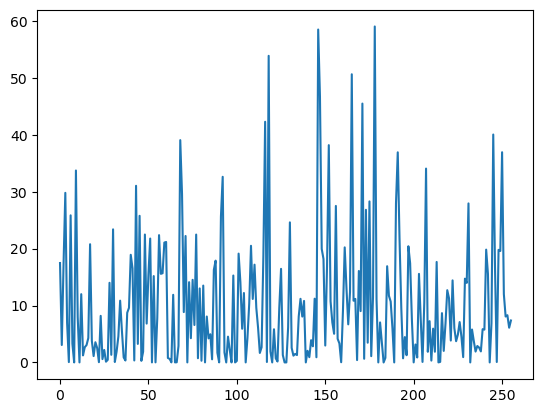

In [117]:
plt.plot(dist_grad[68,:].detach().cpu().numpy())

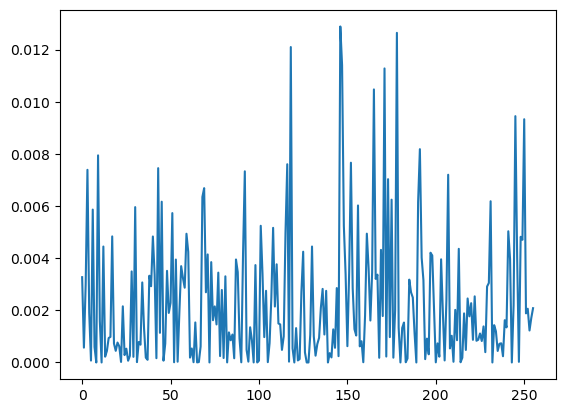

In [123]:
plt.plot(mse_grad[68,:].detach().cpu().numpy())

In [119]:
dist_grad.norm(), mse_grad.norm(), diff_grad.norm()

(tensor(245.5227, device='cuda:0'),
 tensor(0.4199, device='cuda:0'),
 tensor(0.0267, device='cuda:0'))

In [122]:
dist_grad[68,:].mean(), mse_grad.mean(), diff_grad.mean()

(tensor(10.1940, device='cuda:0'),
 tensor(0.0006, device='cuda:0'),
 tensor(3.3471e-06, device='cuda:0'))

In [58]:
list(model.parameters())[-1].grad

tensor([-6.5680e-06, -9.7665e-04,  2.4003e-04, -1.0687e-03, -2.4146e-03,
        -2.8978e-03,  1.4353e-05, -2.8439e-03, -1.8330e-03, -2.8450e-03,
        -2.4598e-03, -8.6902e-04, -1.4212e-03, -1.7811e-03, -3.3171e-04,
         6.9916e-04,  8.2543e-04,  5.4299e-05, -3.0498e-03, -8.9167e-05,
        -1.7023e-06, -1.4055e-03,  6.0010e-04,  1.3157e-03,  1.1865e-04,
         1.1891e-03, -1.8228e-06, -2.6579e-04,  2.1562e-04, -1.4249e-03,
        -2.1210e-03, -5.7293e-04, -6.2522e-04,  4.9325e-04,  2.0208e-03,
        -4.1392e-04, -2.4423e-03, -1.5282e-03, -1.9861e-03,  6.7529e-04,
        -1.2560e-03, -7.6525e-04,  8.5281e-04,  9.9499e-04,  1.9072e-03,
        -1.0712e-03,  1.0485e-03,  1.7634e-03, -1.3485e-03, -9.3937e-05,
         3.6591e-03, -4.0634e-04, -1.0401e-03, -1.2010e-03,  9.4773e-04,
         2.1684e-03,  2.2416e-03,  2.6384e-03, -3.2840e-03,  3.4723e-03,
         2.4546e-02,  2.3541e-02,  2.6104e-02,  2.7771e-02,  2.6884e-02,
         3.0212e-02,  2.7974e-02,  2.9145e-02,  3.1

In [126]:
g_avg = (mse_grad + dist_grad + diff_grad) / 3

In [128]:
g_avg.norm()

tensor(81.8595, device='cuda:0')

In [130]:
run = evals.Run("DiffLossTesting",  "trial4")

In [132]:
run.get("losses", -1)

{'train': {'mse': [4.520799160003662,
   2.8256964683532715,
   1.1895376443862915,
   1.7621129751205444,
   1.4342961311340332,
   1.192665934562683,
   1.4916014671325684,
   1.3880507946014404,
   1.1102529764175415,
   1.5617890357971191,
   1.0700817108154297,
   0.9028483629226685,
   0.7770220637321472,
   0.5733938217163086,
   1.0493241548538208,
   0.6827155947685242,
   1.0807127952575684,
   0.7597998976707458,
   1.0096763372421265,
   0.5520832538604736,
   0.782575249671936,
   0.7182216644287109,
   0.49539607763290405,
   0.6431139707565308,
   0.609764814376831,
   0.7207249402999878,
   0.5749603509902954,
   0.5092129707336426,
   0.5813801288604736,
   0.45768269896507263,
   0.5618503093719482,
   0.5687843561172485,
   0.6241032481193542,
   0.6467448472976685,
   0.30673056840896606,
   0.49873480200767517,
   0.5400065183639526,
   0.3596162796020508,
   0.5455806255340576,
   0.4129326343536377,
   0.4568980932235718,
   0.39928799867630005,
   0.415649175643

# Training behavior  - Diffusion

# Training Behavior - Climsim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)

## Validating Errors

Including incidents of nan or anything else

In [ ]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [ ]:
trainer.bli = 1
trainer.train(1, log=True)

### Investigating Incidents

In [2]:
from diffusionsim.evaluations import *

In [22]:
incident  = trainer.nan_incidents['trial1b'][0]
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



In [21]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


In [236]:
x, y = trainer.dataloaders['train'].dataset[335]
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
print(y_hat.shape, y.shape)
trainer.distribution_loss(y_hat, y, tconfigs[0], 0) # nan? 

In [204]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

In [205]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)
plt.plot(x, density)

In [ ]:
d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [22]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

# Trying to Improve Training

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [ ]:
#two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
batch = next(iter(two_sample_dl))
noisy_images, timesteps, noise = two_sample_dl.dataset.noise_batch(batch)

optimizer = diff.trainers.create_optimizer(model, tconfig)
lr_scheduler = load_lr_scheduler(tconfig, optimizer, two_sample_dl)

In [ ]:
pred = model(noisy_images, timesteps).sample
loss = loss_fn(pred, noise)
loss

In [ ]:
loss.backward()

In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

In [ ]:
torch.norm(list(model.parameters())[0].grad)

In [ ]:
set = {'train' : two_sample_ds}
trainer = DiffusionTrainer(model, dset, loss_fn, tconfig, mconfig, exp_id='two_sample_diffusion')
#trainer.dataloaders = {'train' : two_sample_dl}
#trainer.batch = next(iter(two_sample_dl)) # use same noise every time
trainer.train(1000)

In [ ]:
plt.plot(trainer.losses)

## 

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = load_lr_scheduler(tconfig, )

## Experimenting with Accelerators

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)